
                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  

Database.shape: App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863

/tmp/ipykernel_4052/1470227449.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment", data=df, palette="viridis")


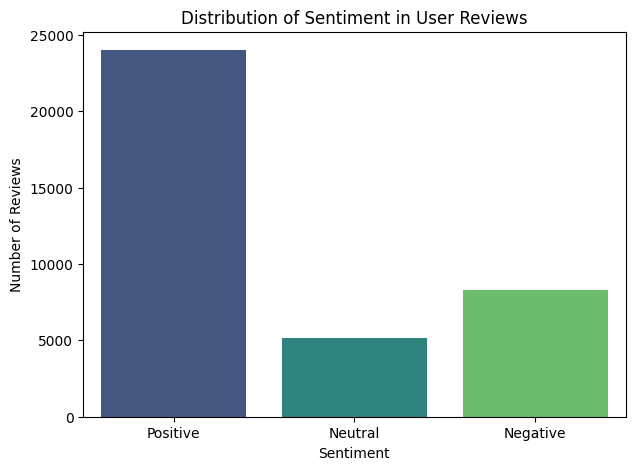

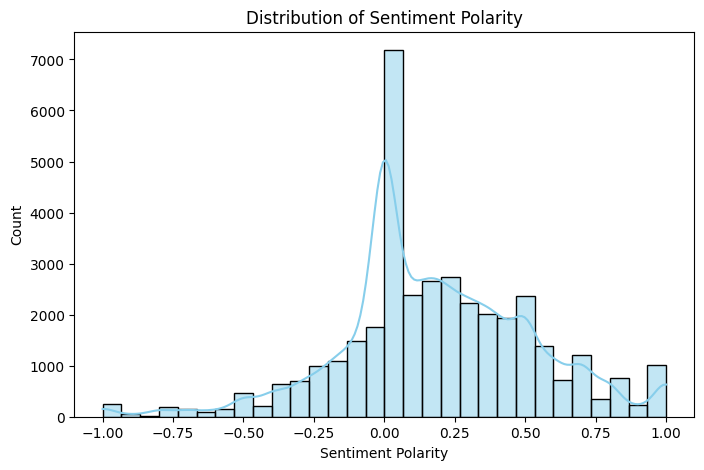

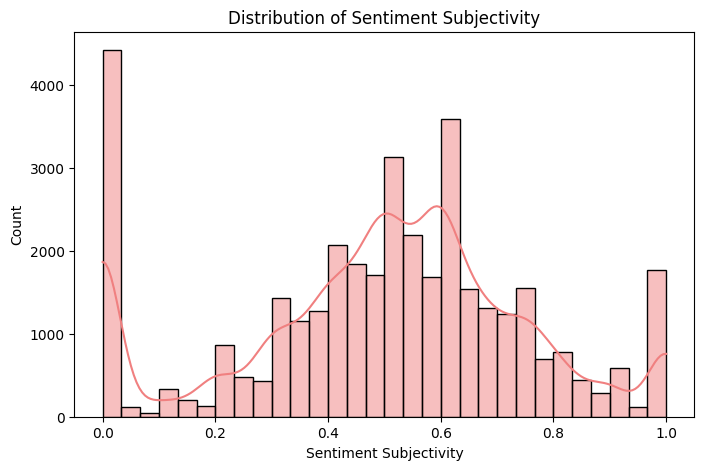

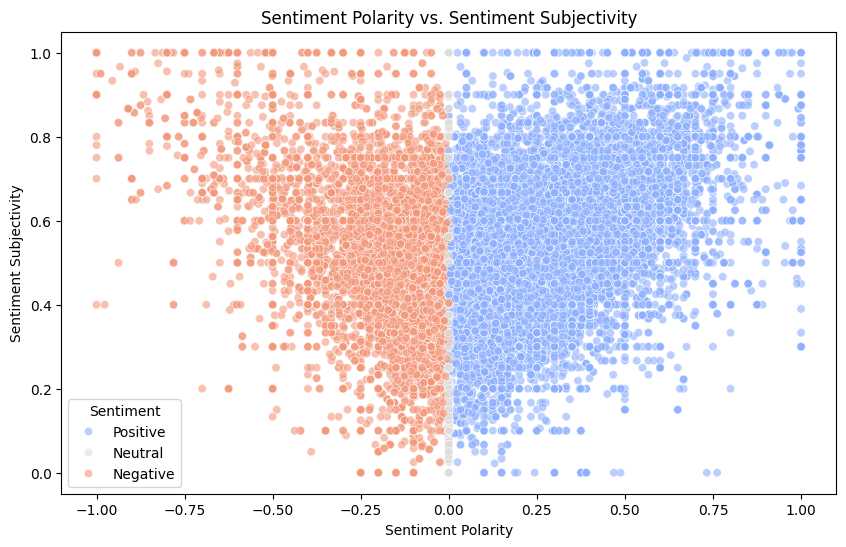

In [1]:
from numpy import shape
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# load database
df = pd.read_csv("/content/googleplaystore_user_reviews.csv")
print("")
#Basic info
print(df.head())
print("\nDatabase.shape:", df.isnull().sum())
# data cleaning
#drop data of missing values
df=df.dropna()
#Convert sentiment polarity and subjectivity to numeric (if not already)
df["Sentiment_Polarity"] = pd.to_numeric(df["Sentiment_Polarity"], errors="coerce")
df["Sentiment_Subjectivity"] = pd.to_numeric(df["Sentiment_Subjectivity"], errors="coerce")

# Insights related to user reviews and sentiment
print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

print("\nAverage Sentiment Polarity by Sentiment:")
print(df.groupby("Sentiment")["Sentiment_Polarity"].mean())

print("\nAverage Sentiment Subjectivity by Sentiment:")
print(df.groupby("Sentiment")["Sentiment_Subjectivity"].mean())


# Visualization 1: Sentiment Distribution
plt.figure(figsize=(7,5))
sns.countplot(x="Sentiment", data=df, palette="viridis")
plt.title("Distribution of Sentiment in User Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# Visualization 2: Distribution of Sentiment Polarity
plt.figure(figsize=(8,5))
sns.histplot(df["Sentiment_Polarity"].dropna(), bins=30, kde=True, color="skyblue")
plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Count")
plt.show()

# Visualization 3: Sentiment Subjectivity Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Sentiment_Subjectivity"].dropna(), bins=30, kde=True, color="lightcoral")
plt.title("Distribution of Sentiment Subjectivity")
plt.xlabel("Sentiment Subjectivity")
plt.ylabel("Count")
plt.show()

# Visualization 4: Sentiment Polarity vs. Subjectivity
plt.figure(figsize=(10,6))
sns.scatterplot(x="Sentiment_Polarity", y="Sentiment_Subjectivity", hue="Sentiment", data=df, alpha=0.6, palette="coolwarm")
plt.title("Sentiment Polarity vs. Sentiment Subjectivity")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.show()


GOOGLE PLAY STORE DATASET ANALYSIS

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018            

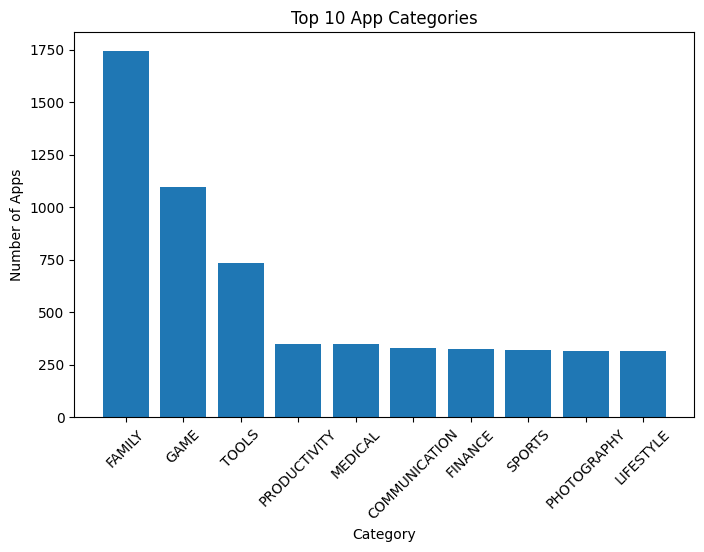

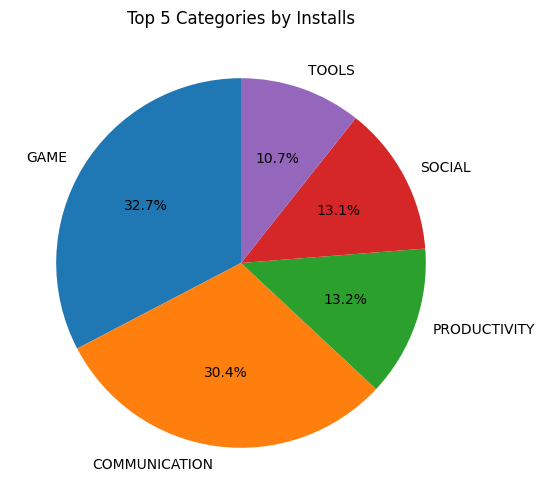

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/content/googleplaystore.csv")

print("GOOGLE PLAY STORE DATASET ANALYSIS\n")

# Basic Information
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Data Cleaning
df = df.dropna()
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Installs"] = df["Installs"].str.replace(",", "", regex=False).str.replace("+", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Insights
print("\nTop 5 Categories:")
print(df["Category"].value_counts().head())

print("\nTop 5 Highest Rated Apps:")
print(df[["App","Rating"]].sort_values("Rating", ascending=False).head())

print("\nAverage Rating:", round(df["Rating"].mean(),2))
print("Average Reviews:", int(df["Reviews"].mean()))

# Visualization 1
top_cat = df["Category"].value_counts().head(10)
plt.figure(figsize=(8,5))
plt.bar(top_cat.index, top_cat.values)
plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

# Visualization 2
install = df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(6,6))
plt.pie(install, labels=install.index, autopct="%1.1f%%", startangle=90)
plt.title("Top 5 Categories by Installs")
plt.show()